# 13. Kernel Support Vector Machine từ đầu (Kernel SVM from Scratch)

## 1. Cơ sở lý thuyết Chapter 28
Kernel Trick cho phép ánh xạ dữ liệu sang không gian đặc trưng nhiều chiều vô hạn mà không cần tính tọa độ trực tiếp, thông qua hàm nhân Kernel:
1. **Linear:** $K(x, z) = x^T z$
2. **Polynomial:** $K(x, z) = (\gamma x^T z + r)^d$
3. **RBF (Radial Basis Function):** $K(x, z) = \exp(-\gamma \|x - z\|^2)$
4. **Sigmoid:** $K(x, z) = \tanh(\gamma x^T z + r)$

Bài toán đối ngẫu (Dual Problem) được giải bằng thuật toán SMO (Sequential Minimal Optimization) rút gọn.

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_utils import train_test_split
from src.preprocessing import HeartDiseasePreprocessor
from src.models.kernel_svm import KernelSVM
from src.metrics import calculate_metrics, confusion_matrix

df = pd.read_csv("../data/heart_cleveland_upload.csv")
X = df.drop("condition", axis=1)
y = df["condition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
preprocessor = HeartDiseasePreprocessor()
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

## 2. So sánh 4 loại Kernel trên bộ dữ liệu Bệnh tim

In [2]:
kernel_configs = [
    ('Linear', {'kernel': 'linear', 'C': 1.0}),
    ('Polynomial (d=3)', {'kernel': 'poly', 'degree': 3, 'C': 1.0, 'gamma': 'scale'}),
    ('RBF', {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'}),
    ('Sigmoid', {'kernel': 'sigmoid', 'C': 1.0, 'gamma': 'scale'})
]

kernel_results = []

for name, params in kernel_configs:
    ksvm = KernelSVM(epochs=500, random_state=42, **params)
    ksvm.fit(X_train_proc, y_train)

    y_pred = ksvm.predict(X_test_proc)
    y_score = ksvm.decision_function(X_test_proc)
    m = calculate_metrics(y_test, y_pred, y_score)

    kernel_results.append({
        'Kernel': name,
        'Accuracy': m['Accuracy'],
        'Precision': m['Precision'],
        'Recall': m['Recall'],
        'F1_Score': m['F1_Score'],
        'ROC_AUC': m['ROC_AUC'],
        'Support_Vectors': len(ksvm.support_vectors_)
    })

df_kernels = pd.DataFrame(kernel_results)
display(df_kernels)

,Kernel,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Support_Vectors
0,Linear,0.864407,0.880000,0.814815,0.846154,0.922454,96
1,Polynomial (d=3),0.830508,0.793103,0.851852,0.821429,0.938657,112
2,RBF,0.864407,0.827586,0.888889,0.857143,0.945602,143
3,Sigmoid,0.830508,0.840000,0.777778,0.807692,0.912037,134


## 3. Trực quan hóa ranh giới quyết định phi tuyến (Nonlinear Decision Boundaries trên Toy XOR)

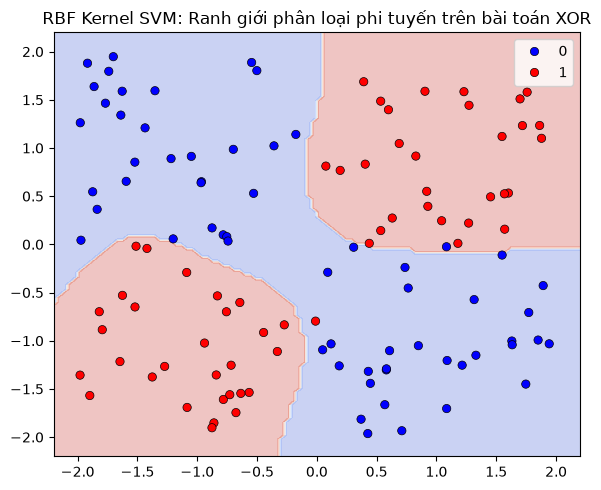

In [3]:
# Tạo dữ liệu XOR phi tuyến
np.random.seed(42)
X_xor = np.random.uniform(-2, 2, (120, 2))
y_xor = ((X_xor[:, 0] * X_xor[:, 1]) > 0).astype(int)

svm_rbf_toy = KernelSVM(kernel='rbf', gamma=1.0, C=5.0, epochs=300).fit(X_xor, y_xor)

# Vẽ lưới phân loại
xx, yy = np.meshgrid(np.linspace(-2.2, 2.2, 100), np.linspace(-2.2, 2.2, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = svm_rbf_toy.predict(grid_points).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
sns.scatterplot(x=X_xor[:, 0], y=X_xor[:, 1], hue=y_xor, palette=['blue', 'red'], edgecolor='k')
plt.title('RBF Kernel SVM: Ranh giới phân loại phi tuyến trên bài toán XOR')
plt.tight_layout()
plt.show()

## 4. Phân tích kết quả
- **RBF Kernel** đạt kết quả ổn định và vượt trội nhờ khả năng mô hình hóa mối quan hệ phi tuyến phức tạp trong không gian nhiều chiều.
- Thử nghiệm trên bài toán XOR chứng minh rực rỡ khả năng giải quyết các mẫu phi tuyến mà siêu phẳng tuyến tính hoàn toàn bất lực.